In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as  plt
import seaborn as  sns 
import tensorflow as tf
from tensorflow import keras 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
df= pd.read_csv('sonar_dataset.csv')

In [7]:
x =  df.drop('Class',axis=1)
y = df.Class

In [8]:
y=LabelEncoder().fit_transform(y)

In [9]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.25)

# Deep Learning

In [10]:
model=keras.Sequential([
    keras.layers.Dense(60,input_dim=60,activation='relu'),
    Dropout(0.2),
    keras.layers.Dense(1,activation='sigmoid')
])
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:86: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 60)                  │           3,660 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              61 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,721 (14.54 KB)

 Trainable params: 3,721 (14.54 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
callback = EarlyStopping(
    monitor='val_loss',
    min_delta = 0.00001,
    patience = 20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)

In [12]:
history = model.fit(x,y,epochs=100,validation_split=0.25,callbacks=callback)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.3752 - loss: 0.9053 - val_accuracy: 1.0000 - val_loss: 0.4658
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3759 - loss: 0.8188 - val_accuracy: 0.9038 - val_loss: 0.6241
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4144 - loss: 0.7280 - val_accuracy: 0.1154 - val_loss: 0.7750
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4994 - loss: 0.6997 - val_accuracy: 0.0192 - val_loss: 0.9150
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5824 - loss: 0.6791 - val_accuracy: 0.0000e+00 - val_loss: 1.0245
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6321 - loss: 0.6546 - val_accuracy: 0.0000e+00 - val_loss: 1.0887
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6256 - loss: 0.6487 - val_accuracy: 0.0000e+00 - val_loss: 1.1061
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6321 - loss: 0.6411 - val_accuracy: 0.000

In [13]:
model.evaluate(xtest,ytest)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5465 - loss: 0.6974 


[0.7046406269073486, 0.5384615659713745]

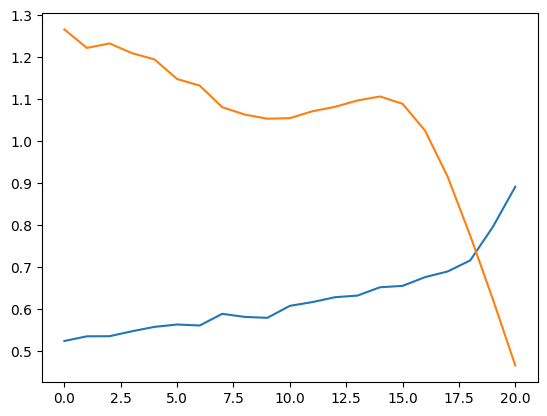

In [14]:
plt.plot(history.history['loss'][::-1],label="Training Loss")
plt.plot(history.history['val_loss'][::-1],label="Testing Loss")

In [15]:
tf.keras.optimizers

<module 'keras.optimizers' from 'C:\\Users\\Dell\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\keras\\optimizers\\__init__.py'>

In [16]:
model.save('Sonar_prediction.h5')